In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-ky31wddm because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


### Importing HCAL data

In [48]:
df = pd.read_csv('hcal_ML.csv', skiprows=[0], header=None)
df = df.drop(293, axis=1) # dropping last col with Nones
print(df.head())
print(df.shape)
print(df.dtypes)

   0    1        2         3         4    5    6    7    8    9    ...  283  \
0    3    0  2.52100 -0.275063  0.277311    0  0.0  0.0  0.0  0.0  ...  0.0   
1    5    1  2.23563 -1.198600  0.171482    0  0.0  0.0  0.0  0.0  ...  0.0   
2    8    1  2.50102 -1.078670  0.358084    0  0.0  0.0  0.0  0.0  ...  0.0   
3   14    1  2.25074 -1.379400 -0.020947    0  0.0  0.0  0.0  0.0  ...  0.0   
4   15    1  2.25876 -1.284660  0.016363    0  0.0  0.0  0.0  0.0  ...  0.0   

   284  285  286  287  288  289  290  291  292  
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[5 rows x 293 columns]
(9958, 293)
0        int64
1        int64
2      float64
3      float64
4      float64
        ...   
288    float64
289    float64
290    float64
291    float64
292    float64
Length: 293, dtype: object


In [43]:
# create a numpy array
data = df.to_numpy()

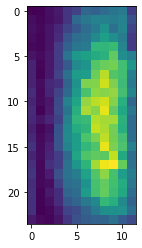

In [44]:
# create a hitmap for visulaization
plt.imshow(np.sum(data[:,5:], axis=0).reshape(24,12))
plt.show()

### Getting traning data

In [53]:
X = data[:, 3:]
Y = data[:, [1]]

In [59]:
from sklearn.model_selection import train_test_split

In [73]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 0, stratify = Y)

### Scaling the data

In [69]:
from sklearn.preprocessing import MinMaxScaler

In [70]:
scaler = MinMaxScaler()
scaler.fit_transform(X_train)
scaler.transform(X_test)

array([[0.84690285, 0.94894412, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.86482287, 0.95558136, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.9329084 , 0.95759573, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.87396442, 0.9522238 , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.8581418 , 0.95665487, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.86579618, 0.95168666, 0.        , ..., 0.        , 0.        ,
        0.        ]])

### Training RandomForest Classifier

In [71]:
from sklearn.ensemble import RandomForestClassifier

In [72]:
rf = RandomForestClassifier(n_estimators = 200, criterion = 'gini', random_state = 0)

In [75]:
rf.fit(X_train, Y_train.ravel())

RandomForestClassifier(n_estimators=200, random_state=0)

### Evaluating the model

In [76]:
from sklearn.metrics import confusion_matrix

In [77]:
Y_pred = rf.predict(X_test)
cm = confusion_matrix(Y_test, Y_pred)

In [79]:
rf.score(X_test, Y_test)

0.9588353413654619